In [2]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [6]:
import seaborn as sns

In [3]:
#Filter for data analyst
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].copy()

#Drop NaN Values from the column for plotting
df_DA_US  = df_DA_US.dropna(subset=['salary_year_avg'])

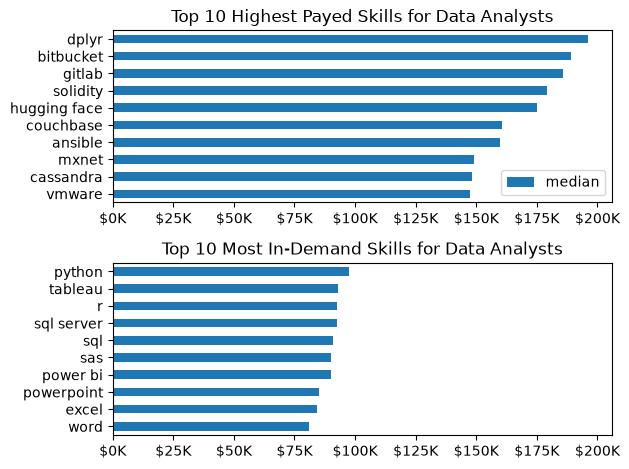

In [7]:
fig,ax = plt.subplots(2,1)

df_DA_top_pay['median'].plot(kind="barh", ax=ax[0], legend=True)
#Can also call the DF in reverse order avoiding need to invert axis
#df_DA_top_pay[::-1].plot'...'
ax[0].invert_yaxis()
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_title('Top 10 Highest Payed Skills for Data Analysts')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))

df_DA_skills['median'].plot(kind="barh", ax=ax[1])
ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

# Using Seaborn to plot the same data

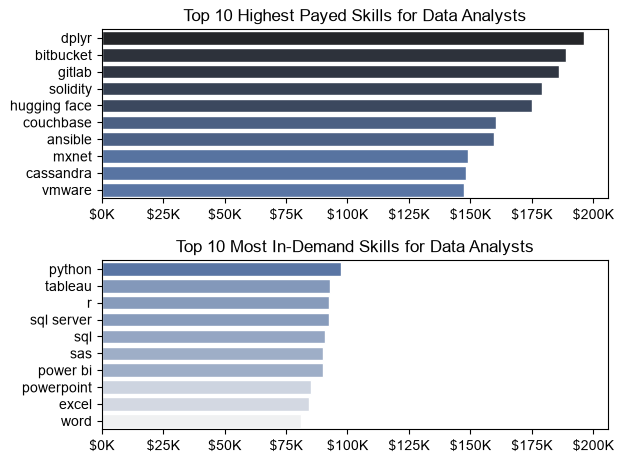

In [17]:
fig,ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

sns.barplot(data = df_DA_top_pay, x='median', y = df_DA_top_pay.index, ax=ax[0], hue='median', palette = 'dark:b_r')

#df_DA_top_pay['median'].plot(kind="barh", ax=ax[0], legend=True)
#Can also call the DF in reverse order avoiding need to invert axis
#df_DA_top_pay[::-1].plot'...'
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_title('Top 10 Highest Payed Skills for Data Analysts')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))
ax[0].legend().remove()

sns.barplot(data = df_DA_skills, x='median', y = df_DA_skills.index, ax=ax[1],hue='median', palette = 'light:b')
#df_DA_skills['median'].plot(kind="barh", ax=ax[1])
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))
ax[1].legend().remove()

plt.tight_layout()
plt.show()

# Using Seaborn to plot the Histogram Plot

Text(0, 0.5, 'Number of Jobs')

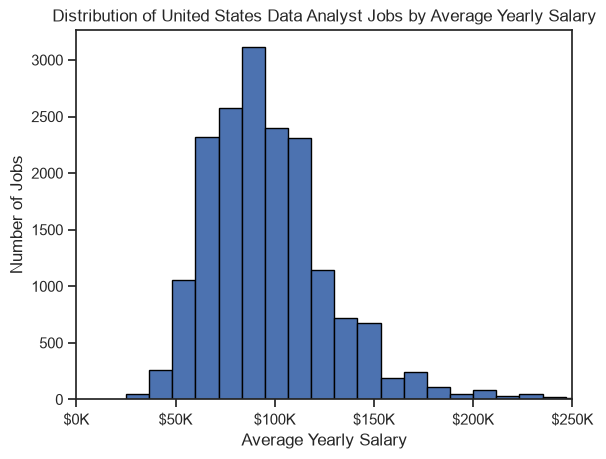

In [18]:
df_DA_US['salary_year_avg'].plot(kind='hist',bins=30,edgecolor='black')
plt.xlim(0,250000)

ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}K'))

plt.title('Distribution of United States Data Analyst Jobs by Average Yearly Salary')
plt.xlabel('Average Yearly Salary')
plt.ylabel('Number of Jobs')

Text(12.444444444444445, 0.5, 'Number of Jobs')

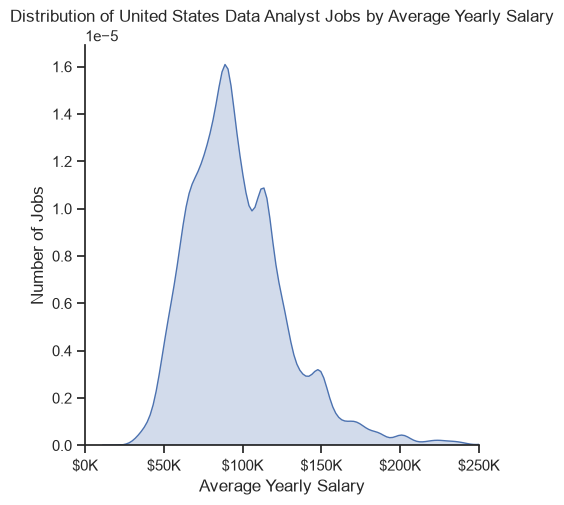

In [22]:
sns.displot(data=df_DA_US['salary_year_avg'], kind='kde', fill=True) #kde = kernel density estimation
plt.xlim(0,250000)

ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}K'))

plt.title('Distribution of United States Data Analyst Jobs by Average Yearly Salary')
plt.xlabel('Average Yearly Salary')
plt.ylabel('Number of Jobs')

# Using Seaborn to plot the Boxplot graph

C:\Users\Avrah\AppData\Local\Temp\ipykernel_13168\2824838362.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list,tick_labels=job_titles,vert=False)


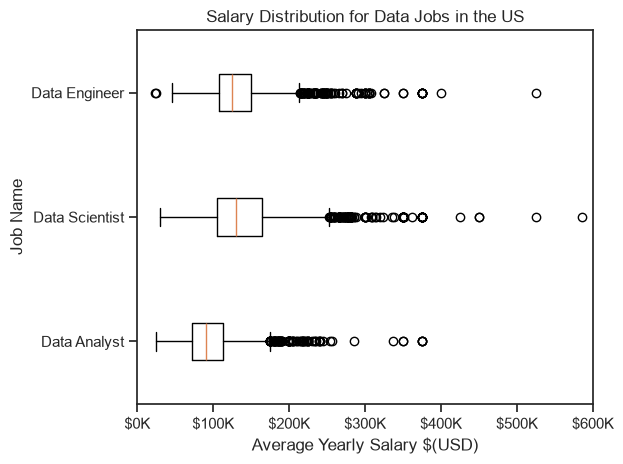

In [23]:
#Create a list of desired job titles
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

#Filter for desired job titles and only in the US.
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

#We want to create a *LIST* of the average yearly salary for the given filters.
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list,tick_labels=job_titles,vert=False)
plt.title('Salary Distribution for Data Jobs in the US')
plt.xlabel('Average Yearly Salary $(USD)')
plt.ylabel('Job Name')
plt.xlim(0,600000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

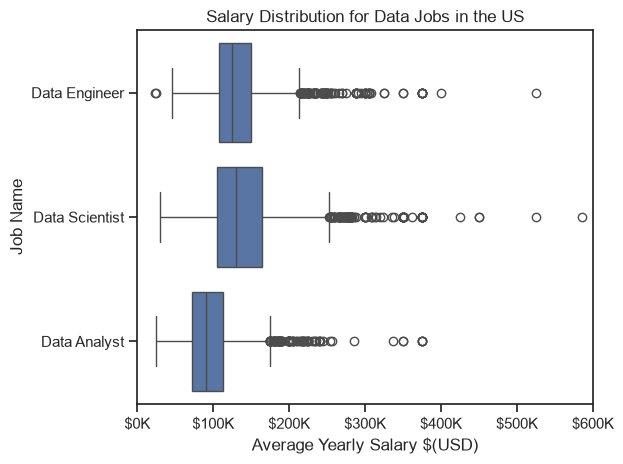

In [25]:
sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short')

plt.title('Salary Distribution for Data Jobs in the US')
plt.xlabel('Average Yearly Salary $(USD)')
plt.ylabel('Job Name')
plt.xlim(0,600000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()